# Materials for Heat Diffusion

One of the important experiments we cover are solving the heat equation over material with various diffusivities. Here, we will cover the `Material` class API:

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')
import os

# change current working directory to the project root
os.chdir('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

## Airplane

An arbitrary domain, but with a specific domain shape.

# of coordinates: 250000


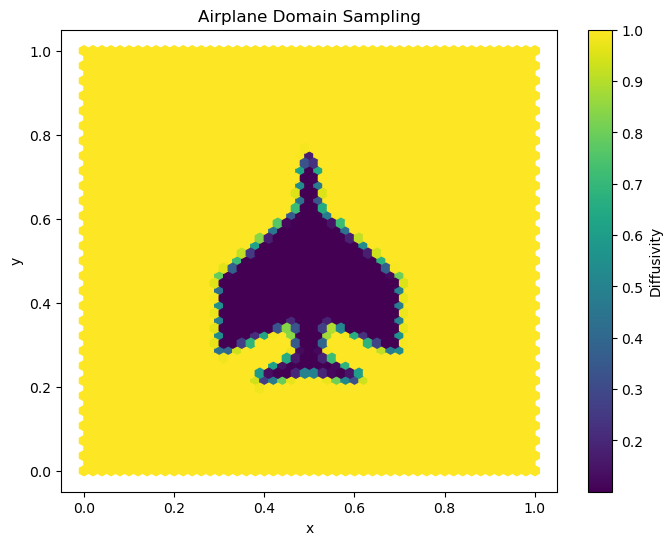

In [2]:
%autoreload 2
from infidictionary.material import AirplaneMaterial

airplane_material = AirplaneMaterial(
    min_diffusivity=0.1,
    max_diffusivity=1.0,
    length=2.6,
)

coords = airplane_material.domain_sampler.sample(500)
diffusivity = airplane_material(coords)
print("# of coordinates:", coords.shape[0])
# now plot a hexbin with the diffusivity as the color
plt.figure(figsize=(8, 6))
plt.hexbin(
    coords[:, 0].detach().cpu(), 
    coords[:, 1].detach().cpu(), 
    C=diffusivity.detach().cpu(),
    gridsize=50, cmap=plt.cm.viridis, mincnt=1,
)
plt.colorbar(label='Diffusivity')
plt.title('Airplane Domain Sampling')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


## Joseph Fourier Material

A whimsical material where the portrait of Joseph Fourier dictates the diffusivity:

# of coordinates: 250000


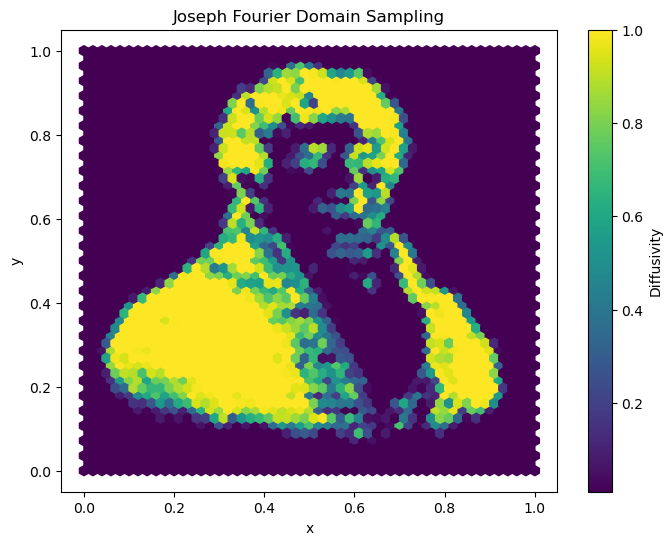

In [3]:
%autoreload 2
from infidictionary.material import JosephFourierMaterial

joseph_material = JosephFourierMaterial(
    image_path='./assets/Joseph_Fourier.jpg',
    image_size=256,
    min_diffusivity=0.01,
    max_diffusivity=1.0,
    threshold=0.5,
    # stratified=True,
    # add_nosie=True,
)
coords = joseph_material.domain_sampler.sample(500)
print("# of coordinates:", coords.shape[0])
# now plot a hexbin with the diffusivity as the color
plt.figure(figsize=(8, 6))
plt.hexbin(
    coords[:, 0].detach().cpu(),
    coords[:, 1].detach().cpu(),
    C=joseph_material(coords).detach().cpu(),
    gridsize=50, cmap=plt.cm.viridis, mincnt=1,
)
plt.colorbar(label='Diffusivity')
plt.title('Joseph Fourier Domain Sampling')
plt.xlabel('x')
plt.ylabel('y')
plt.show()


## Smoothing Diffusivities

Performs Gaussian blurring to make the diffusivity more tractable.

# of coordinates: 62500


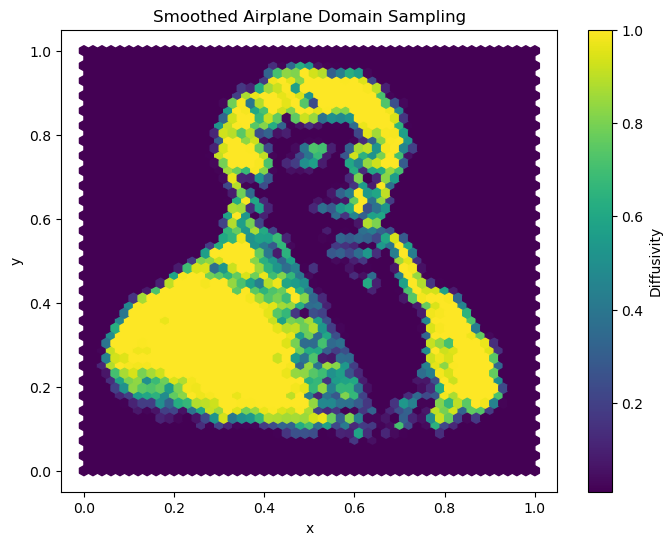

In [11]:
%autoreload 2
from infidictionary.material import JosephFourierMaterial

smoothed_material = JosephFourierMaterial(
    image_path="assets/Joseph_Fourier.jpg",
    image_size=256,
    min_diffusivity=0.01,
    max_diffusivity=1.0,
    threshold=0.5,
    sigma=0.002
)
coords = smoothed_material.domain_sampler.sample(250)
print("# of coordinates:", coords.shape[0])
# now plot a hexbin with the diffusivity as the color
plt.figure(figsize=(8, 6))
plt.hexbin(
    coords[:, 0].detach().cpu(),
    coords[:, 1].detach().cpu(),
    C=smoothed_material(coords).detach().cpu(),
    gridsize=50, cmap=plt.cm.viridis, mincnt=1,
)
plt.colorbar(label='Diffusivity')
plt.title('Smoothed Airplane Domain Sampling')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Numerical Ground-Truth Eigenfunctions (FDM)

Solve $-\nabla\cdot(D(x)\,\nabla f) = \lambda f$ on a regular $n\times n$ grid
with **periodic boundary conditions** using finite differences.

The weighted Laplacian is assembled as a sparse matrix and the `N_TRUNC` smallest
eigenpairs are found via `scipy.sparse.linalg.eigsh` with shift-invert
($\sigma\approx 0$).  These are the ground-truth vibrational modes against which
the learned pushforward can be compared.

In [12]:
# Material to use for the numerical ground-truth solver.
# Swap this to any Material with a SquareSampler domain.
fdm_material = smoothed_material

FDM_GRID_N = 80   # grid resolution: FDM_GRID_N × FDM_GRID_N points
N_TRUNC    = 16   # number of eigenfunctions to compute

In [13]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

n  = FDM_GRID_N
N2 = n * n
h  = 1.0 / n          # grid spacing (periodic: n points tile [0, 1))

# ── Evaluate D on the grid ────────────────────────────────────────────────────
xs       = torch.linspace(0, 1 - h, n, dtype=torch.float64)
xv, yv   = torch.meshgrid(xs, xs, indexing='ij')           # (n, n)
grid_pts = torch.stack([xv.reshape(-1), yv.reshape(-1)], dim=1)  # (n², 2)

with torch.no_grad():
    D_np = fdm_material(grid_pts).cpu().numpy().reshape(n, n)  # (n, n)

# ── Half-point diffusivities (periodic averages) ──────────────────────────────
D_xp = (D_np + np.roll(D_np, -1, axis=0)) / 2   # D_{i+½, j}
D_xm = (D_np + np.roll(D_np,  1, axis=0)) / 2   # D_{i-½, j}
D_yp = (D_np + np.roll(D_np, -1, axis=1)) / 2   # D_{i, j+½}
D_ym = (D_np + np.roll(D_np,  1, axis=1)) / 2   # D_{i, j-½}

D_xp_f = D_xp.reshape(-1)
D_xm_f = D_xm.reshape(-1)
D_yp_f = D_yp.reshape(-1)
D_ym_f = D_ym.reshape(-1)

inv_h2 = 1.0 / h**2

# ── Build sparse weighted Laplacian L ─────────────────────────────────────────
# Flat index: k = i*n + j
k    = np.arange(N2)
i, j = k // n, k % n

k_xp = ((i + 1) % n) * n + j
k_xm = ((i - 1) % n) * n + j
k_yp = i * n + (j + 1) % n
k_ym = i * n + (j - 1) % n

diag   = (D_xp_f + D_xm_f + D_yp_f + D_ym_f) * inv_h2
rows   = np.tile(k, 5)
cols   = np.concatenate([k, k_xp, k_xm, k_yp, k_ym])
data   = np.concatenate([diag, -D_xp_f * inv_h2, -D_xm_f * inv_h2,
                                -D_yp_f * inv_h2, -D_ym_f * inv_h2])

L = sp.csr_matrix((data, (rows, cols)), shape=(N2, N2))

# ── Solve for smallest N_TRUNC eigenpairs (shift-invert for stability) ────────
fdm_eigvals, fdm_eigvecs = spla.eigsh(L, k=N_TRUNC, which='LM', sigma=1e-8)
order        = np.argsort(fdm_eigvals)
fdm_eigvals  = fdm_eigvals[order]
fdm_eigvecs  = fdm_eigvecs[:, order]   # (N², N_TRUNC)

print("Eigenvalues:", np.round(fdm_eigvals, 4))

Eigenvalues: [-0.      0.6232  0.9287  1.0813  1.5573  1.7662  1.8741  2.3106  2.6177
  2.9212  3.1711  3.2691  3.6729  3.7079  4.1347  4.3922]


/tmp/ipykernel_2429045/3529557199.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


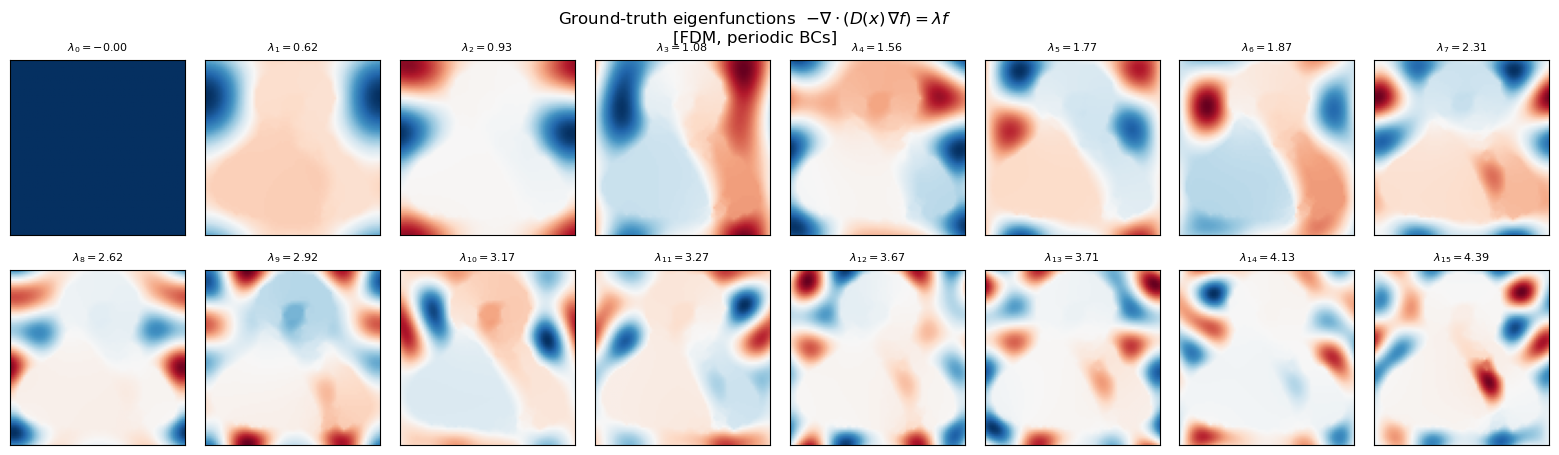

In [14]:
ncols = min(8, N_TRUNC)
nrows = (N_TRUNC + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 2.5, nrows * 2.5),
                          gridspec_kw={'wspace': 0.05, 'hspace': 0.20})
axes = np.array(axes).reshape(nrows, ncols)

for idx in range(N_TRUNC):
    ax = axes[idx // ncols, idx % ncols]
    # rows = y axis, cols = x axis
    f = fdm_eigvecs[:, idx].reshape(FDM_GRID_N, FDM_GRID_N).T
    vmax = np.abs(f).max() + 1e-8
    ax.imshow(f, origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
              extent=[0, 1, 0, 1])
    ax.set_title(f'$\\lambda_{{{idx}}}={fdm_eigvals[idx]:.2f}$', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

for idx in range(N_TRUNC, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle(r'Ground-truth eigenfunctions  $-\nabla\cdot(D(x)\,\nabla f)=\lambda f$'
             '\n[FDM, periodic BCs]', fontsize=12)
plt.tight_layout()
plt.show()

## Load Vibrational-Modes Checkpoint

After running `vibrational_modes.py` (e.g. with `+experiment=airplane_vibration`),
a checkpoint folder is created at `outputs/checkpoints/wandb-<id>/`.
Set `CKPT_DIR` and `CKPT_FILE` below to point to a saved run.

The checkpoint stores only `models['neural_isometry']`; the material and
dictionary are re-instantiated from `config.yaml` in the same directory.

In [49]:
%autoreload 2
import yaml
from omegaconf import OmegaConf
from hydra.utils import instantiate
from infidictionary.neural_isometries import NeuralIsometry
from infidictionary.dictionaries import InfiDictionary
from infidictionary.material import Material

# ── Point to a checkpoint produced by vibrational_modes.py ───────────────────
# CKPT_DIR  = "outputs/checkpoints/wandb-da3hbxp1"  # edit this
CKPT_DIR  = "outputs/checkpoints/wandb-md4x5g0j"

CKPT_FILE = "step_5600.pt"                                 # or "step_N.pt"
# ─────────────────────────────────────────────────────────────────────────────

with open(f"{CKPT_DIR}/config.yaml") as f:
    vib_conf = OmegaConf.create(yaml.safe_load(f))

vib_isometry: NeuralIsometry       = instantiate(vib_conf.neural_isometry).to(device)
vib_dictionary: InfiDictionary     = instantiate(vib_conf.initial_dictionary)
vib_material: Material             = instantiate(vib_conf.material)

ckpt = torch.load(f"{CKPT_DIR}/{CKPT_FILE}", map_location=device, weights_only=False)
vib_isometry.load_state_dict(ckpt["models"]["neural_isometry"])

vib_model_state_kwargs   = dict(vib_conf.get("model_state_kwargs",   {"num_steps": 200}))
vib_pushforward_kwargs   = dict(vib_conf.get("pushforward_kwargs",   {"start_time": 0.0, "end_time": 1.0}))

vib_isometry.shuffle_model_state(**vib_model_state_kwargs)
vib_isometry.eval()

print(f"Loaded   : {CKPT_DIR}/{CKPT_FILE}  (epoch {ckpt['epoch']})")
print(f"Metric   : {ckpt['metric']:.6f}  |  best: {ckpt['best_metric']:.6f}")
print(f"Material : {type(vib_material).__name__}")


Loaded   : outputs/checkpoints/wandb-md4x5g0j/step_5600.pt  (epoch 5599)
Metric   : 227.602402  |  best: 188.594589
Material : JosephFourierMaterial


## Diffusivity Field

Show the spatially varying diffusivity $D(x)$ of the material
the isometry was trained on.

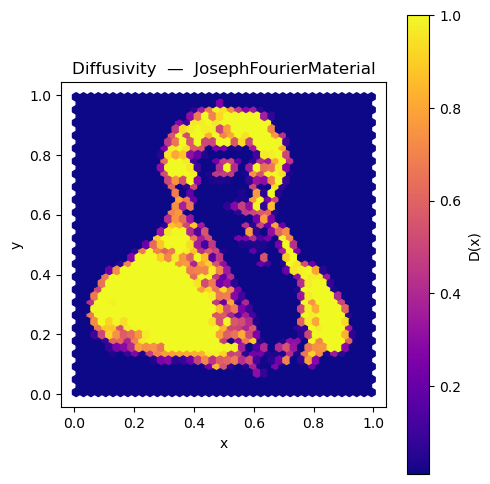

In [50]:
from infidictionary.domain_samplers import SquareSampler

N_VIZ = 80  # resolution for diffusivity and atom grids

grid_coords    = SquareSampler(stratified=True, add_noise=False).sample(N_VIZ).to(device)
grid_logabsdet = torch.zeros(grid_coords.shape[0], device=device)

with torch.no_grad():
    grid_diffusivity = vib_material(grid_coords).cpu().numpy()  # (N_VIZ^2,)

gx = grid_coords[:, 0].cpu().numpy()
gy = grid_coords[:, 1].cpu().numpy()

fig, ax = plt.subplots(figsize=(5, 5))
hb = ax.hexbin(gx, gy, C=grid_diffusivity, gridsize=N_VIZ // 2,
               cmap='plasma', reduce_C_function=np.mean)
plt.colorbar(hb, ax=ax, label='D(x)')
ax.set_title(f'Diffusivity  —  {type(vib_material).__name__}')
ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()


## Fourier Atoms vs. Learned Vibrational Modes

Each tile shows one atom $\phi_{k_1,k_2}$ evaluated on a regular grid.

- **Left** — original Fourier atoms $\phi_{k_1,k_2}(x)$
- **Right** — learned vibrational modes $Q\phi_{k_1,k_2}(x)$

Rows index $k_1$ (vertical frequency), columns $k_2$ (horizontal frequency).
Diverging colourmap centred at zero: blue = negative, red = positive.

`NUM_TRUNCATED` controls the spatial half-bandwidth: $(2 \cdot \text{NUM\_TRUNCATED} - 1)^2$ atoms total.

In [53]:
NUM_TRUNCATED = 5   # spatial half-bandwidth
TILE_SIZE     = 2.0
HEXGRIDSIZE   = 10

# ── Index set (single channel for vibrational modes) ──────────────────────────
indices = vib_dictionary.get_truncated_indices(num_truncated=NUM_TRUNCATED)
idx_np  = indices.cpu().numpy()  # (A, 3): k1, k2, channel
print(f"Indices: {indices.shape}  "
      f"(k range {idx_np[:, :-1].min()} to {idx_np[:, :-1].max()}, "
      f"channels {list(set(idx_np[:, -1].tolist()))})")

k1_vals = sorted(set(int(v) for v in idx_np[:, 0]))
k2_vals = sorted(set(int(v) for v in idx_np[:, 1]))

# Map (k1, k2) -> row index in `indices` (channel 0 only)
spatial_lookup = {
    (int(idx_np[i, 0]), int(idx_np[i, 1])): i
    for i in range(len(idx_np))
    if int(idx_np[i, -1]) == 0
}

# ── Evaluate atoms on a regular grid ─────────────────────────────────────────
with torch.no_grad():
    vib_atoms = vib_dictionary.get_atoms(grid_coords, indices.to(device))  # (A, N, C)
    vib_isometry.shuffle_model_state(**vib_model_state_kwargs)
    _, _, vib_deformed = vib_isometry.pushforward(
        src_coords=grid_coords,
        src_logabsdet=grid_logabsdet,
        src_field=vib_atoms,
        **vib_pushforward_kwargs,
    )  # (A, N, C)

vib_atoms_np    = vib_atoms.cpu().numpy()    # (A, N, 1)
vib_deformed_np = vib_deformed.cpu().numpy() # (A, N, 1)

print(f"atoms:    {vib_atoms_np.shape}")
print(f"deformed: {vib_deformed_np.shape}")


Indices: torch.Size([81, 3])  (k range -4 to 4, channels [0])
atoms:    (81, 6400, 1)
deformed: (81, 6400, 1)


/tmp/ipykernel_2429045/799239344.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


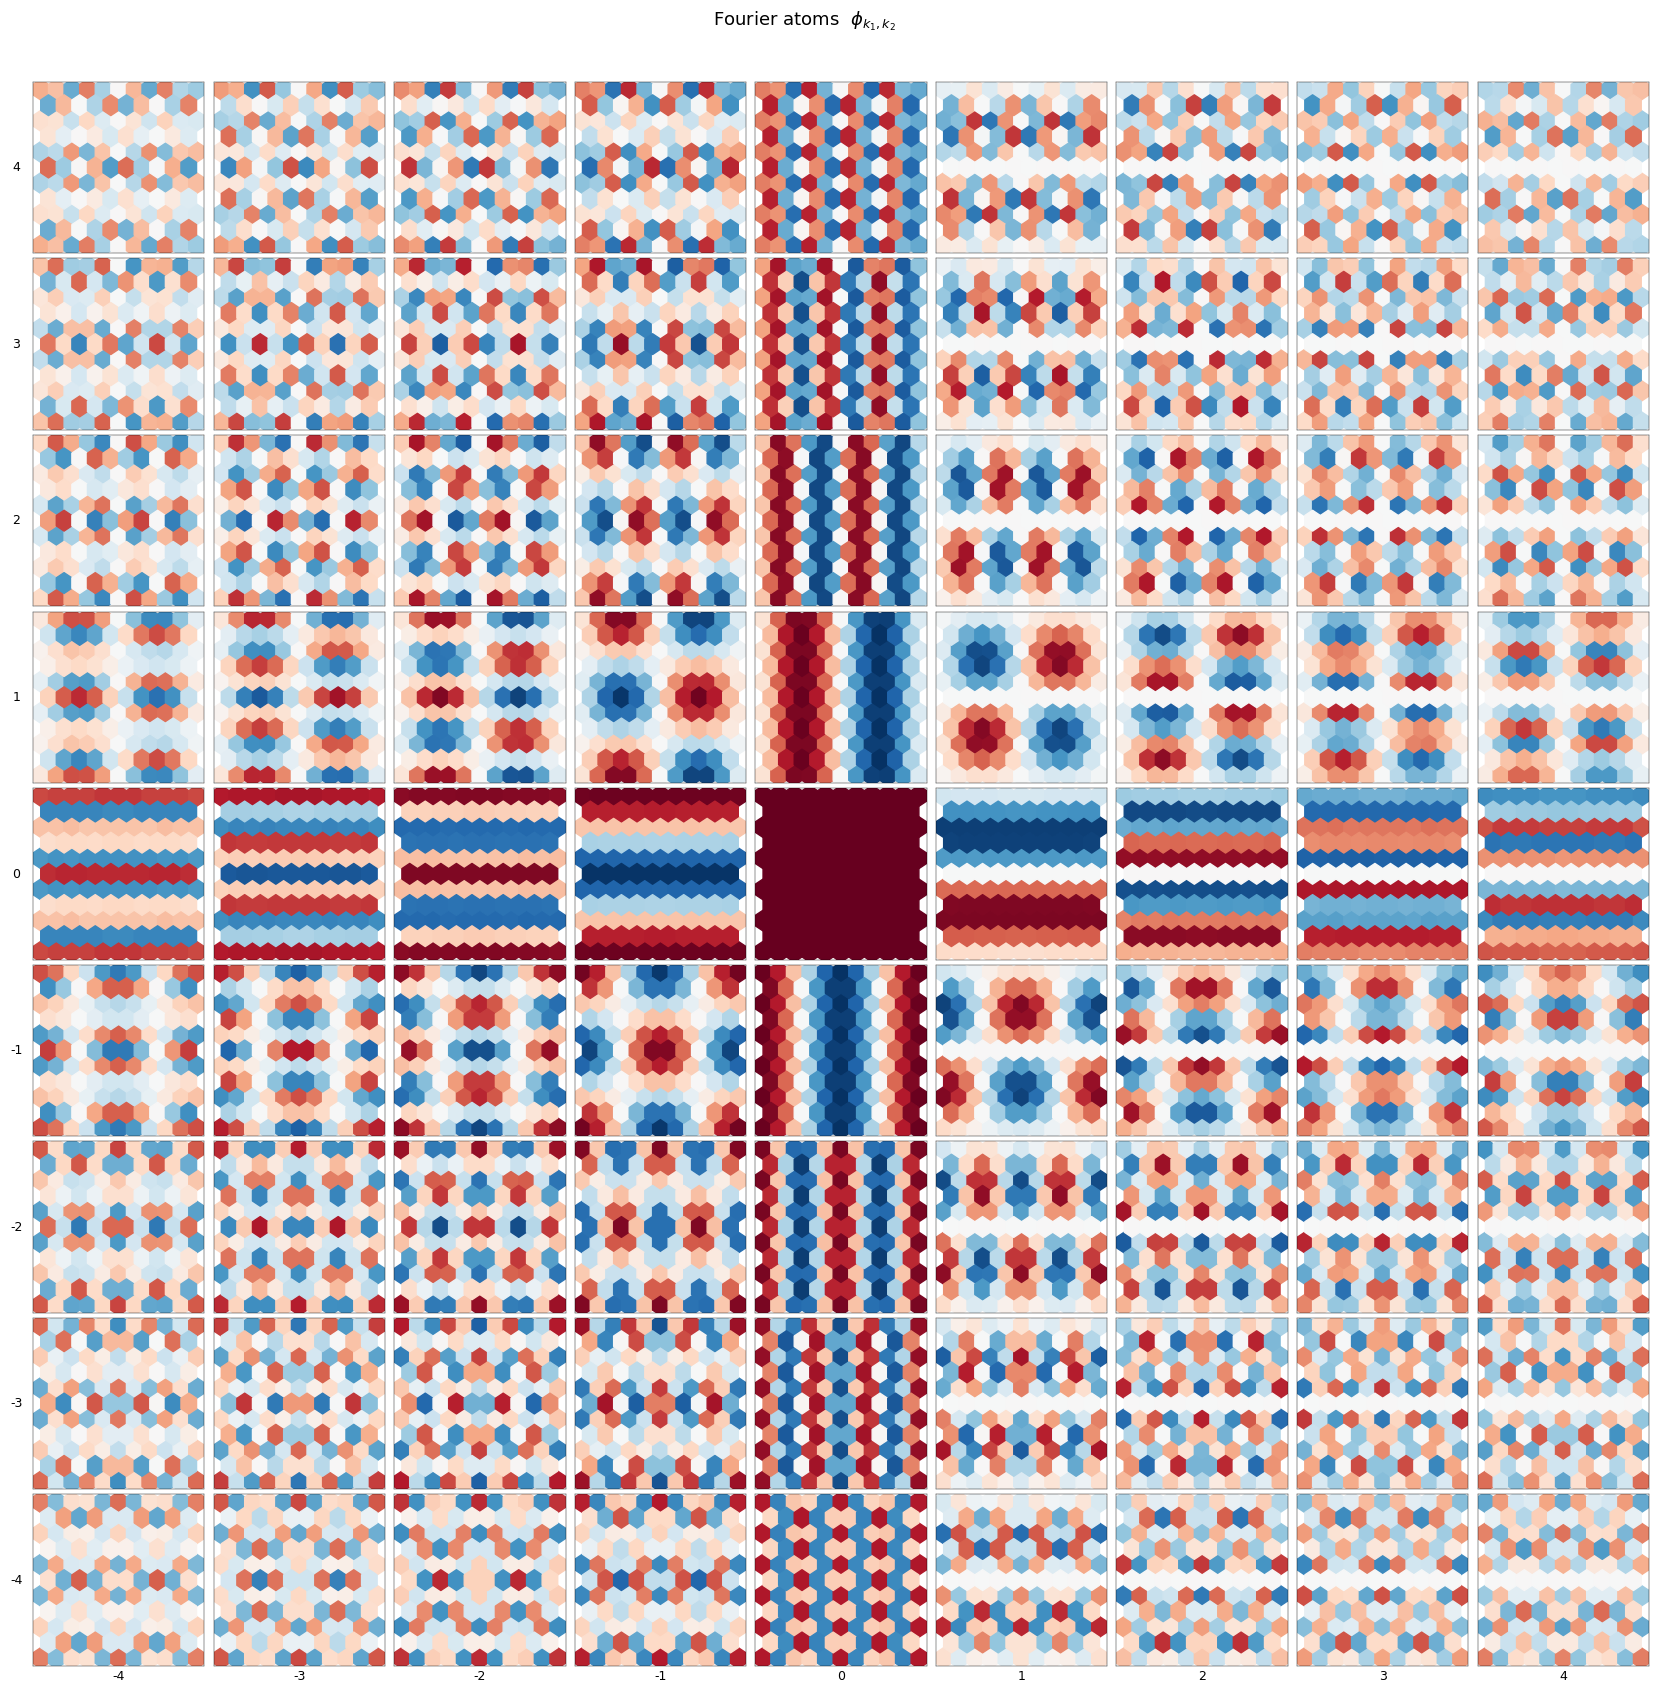

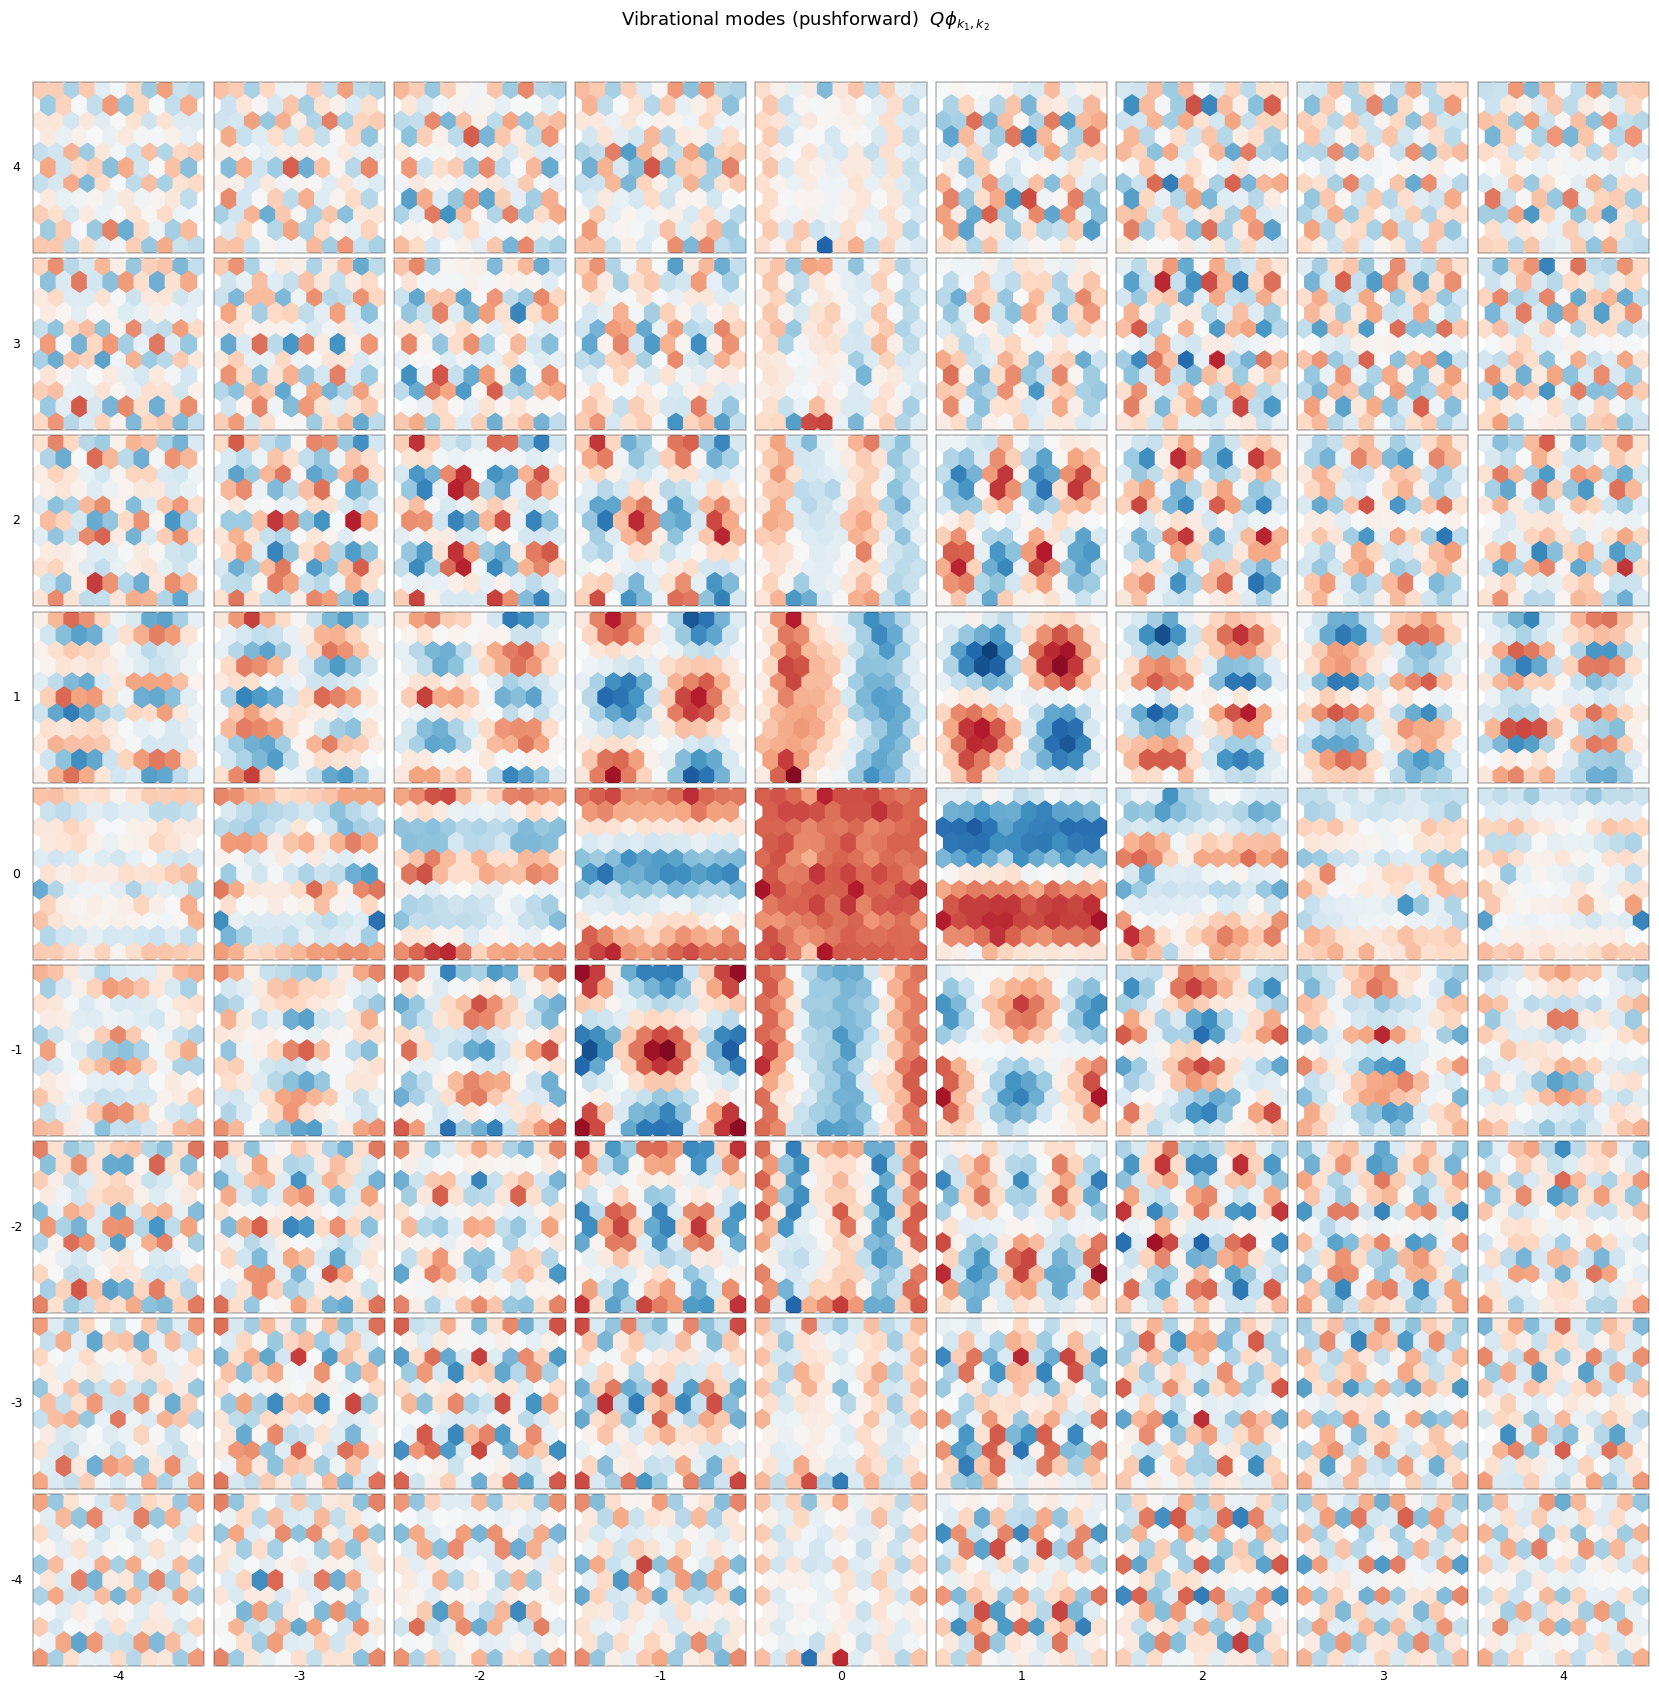

In [54]:
nk1    = len(k1_vals)
nk2    = len(k2_vals)
k1_rev = list(reversed(k1_vals))


def plot_atom_grid(atoms_arr: np.ndarray, title: str) -> None:
    """atoms_arr: (A, N, C) — only channel 0 is shown."""
    fig, axes = plt.subplots(
        nk1, nk2,
        figsize=(nk2 * TILE_SIZE, nk1 * TILE_SIZE),
        gridspec_kw={"wspace": 0.03, "hspace": 0.03},
    )
    fig.subplots_adjust(left=0.07, right=0.97, bottom=0.06, top=0.94)

    for ri, k1 in enumerate(k1_rev):
        for ci, k2 in enumerate(k2_vals):
            ax = axes[ri, ci]
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_linewidth(0.3)

            key = (int(k1), int(k2))
            if key not in spatial_lookup:
                ax.set_facecolor('#ddd')
                continue

            vals = atoms_arr[spatial_lookup[key], :, 0]  # (N,)
            vmax = np.abs(vals).max() + 1e-8
            ax.hexbin(gx, gy, C=vals, reduce_C_function=np.mean,
                      gridsize=HEXGRIDSIZE, cmap='RdBu_r',
                      vmin=-vmax, vmax=vmax)
            ax.set_aspect('equal')

            if ri == nk1 - 1:
                ax.set_xlabel(str(k2), fontsize=9, labelpad=3)
            if ci == 0:
                ax.set_ylabel(str(k1), fontsize=9, rotation=0,
                              labelpad=12, va='center')

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


plot_atom_grid(vib_atoms_np,    r"Fourier atoms  $\phi_{k_1,k_2}$")
plot_atom_grid(vib_deformed_np, r"Vibrational modes (pushforward)  $Q\phi_{k_1,k_2}$")
